In [1]:
# Step 1: Import the required libraries
import pandas as pd
from google.colab import files

# Step 2: Upload the CSV file
uploaded = files.upload()

# Step 3: Read the uploaded CSV file
# Get the filename (assuming only one file uploaded)
for filename in uploaded.keys():
    print(f"\nFile '{filename}' uploaded successfully!")

# Step 4: Load into a pandas DataFrame
df1 = pd.read_csv(filename)

# Step 5: Display first few rows
print("\nPreview of the dataset:")
df1.head()


Saving bengaluru_house_prices.csv to bengaluru_house_prices.csv

File 'bengaluru_house_prices.csv' uploaded successfully!

Preview of the dataset:


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.figsize']=(20,10)

In [3]:
df1.shape

(13320, 9)

In [4]:
df1.groupby('area_type')['area_type'].agg('count')

,area_type
area_type,
Built-up Area,2418
Carpet Area,87
Plot Area,2025
Super built-up Area,8790


In [5]:
df2=df1.drop(['area_type','availability','society','balcony'],axis=1)

In [6]:
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [7]:
df2.isnull().sum()

,0
location,1
size,16
total_sqft,0
bath,73
price,0


In [8]:
df3=df2.dropna()

In [9]:
df3.isna().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [10]:
df3['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [11]:
df3['bhk']=df3['size'].apply(lambda x:x.split(' ')[0])

/tmp/ipython-input-1503208980.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk']=df3['size'].apply(lambda x:x.split(' ')[0])


In [12]:
df3 = df2.dropna().copy()
df3['bhk'] = df3['size'].apply(lambda x: x.split(' ')[0])

display(df3.head())

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [13]:
df3['bhk'].unique()

array(['2', '4', '3', '6', '1', '8', '7', '5', '11', '9', '27', '10',
       '19', '16', '43', '14', '12', '13', '18'], dtype=object)

In [14]:
df3.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [15]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [16]:
df3[~df3['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [17]:
def convertsqft_tonum(x):
    tokens=x.split('-')
    if(len(tokens)==2):
        return (float(tokens[0])+float(tokens[1]))/2

    try:
        return float(x)
    except:
        return None

In [18]:
convertsqft_tonum('2166')

2166.0

In [19]:
convertsqft_tonum('1100-1200')

1150.0

In [20]:
df4=df3.copy()

In [21]:
df4['total_sqft']=df4['total_sqft'].apply(convertsqft_tonum)

In [22]:
df4['total_sqft'].unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ])

In [23]:
df4.loc[30]

,30
location,Yelahanka
size,4 BHK
total_sqft,2475.0
bath,4.0
price,186.0
bhk,4


In [24]:
df5=df4.copy()

In [25]:
df5.head(3)



,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3


In [26]:
df5['price_per_sqft']=df5['price']*100000/df5['total_sqft']
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [27]:
len(df5.location.unique())

1304

In [28]:
df5['location']=df5['location'].apply(lambda x:x.strip())

In [29]:
location_stats=df5.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

,location
location,
Whitefield,535
Sarjapur Road,392
Electronic City,304
Kanakpura Road,266
Thanisandra,236
...,...
poornaprajna layout,1
pavitra paradise,1
near Ramanashree California resort,1


First, let's identify the locations that have a significant number of properties (e.g., more than 10) to make the visualization meaningful. We will then plot these top locations.

Now, let's visualize the counts of these top locations using a bar chart.

In [30]:
len(location_stats[location_stats<10])

1039

In [31]:
location_stats_less_that_10=location_stats[location_stats<=10]
location_stats_less_that_10

,location
location,
Kalkere,10
Sadashiva Nagar,10
BTM 1st Stage,10
Basapura,10
Gunjur Palya,10
...,...
poornaprajna layout,1
pavitra paradise,1
near Ramanashree California resort,1


In [32]:
df5.location=df5.location.apply(lambda x:'other' if x in location_stats_less_that_10 else x)

In [33]:
len(df5.location.unique())

242

In [34]:
df5.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247.863248
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467.057101
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181.818182
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828.244275
9,other,6 Bedroom,1020.0,6.0,370.00,6,36274.509804


In [35]:
def convert_to_float(x):
    try:
        float(x)
    except:
        return False
    return float(x)

In [36]:
df5['bhk']=df5['bhk'].apply(convert_to_float)

In [37]:
df5['total_sqft']=df5['total_sqft'].apply(convert_to_float)

In [38]:
df5.shape

(13246, 7)

In [39]:
df6=df5[~(df5['total_sqft']/df5['bhk']<300)]
df6.shape

(12502, 7)

In [40]:
df6.head(3)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2.0,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4.0,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3.0,4305.555556


In [41]:
df6.price_per_sqft.describe()

,price_per_sqft
count,12456.000000
mean,6308.502826
std,4168.127339
min,267.829813
25%,4210.526316
50%,5294.117647
75%,6916.666667
max,176470.588235


The average price per sqft is

₹6,308.

But prices range widely — from ₹267 to ₹1.7 lakh per sqft.

This indicates the dataset has outliers, likely due to:

Data entry errors (wrong units)

Very high-end luxury properties

Incorrect total_sqft or price values

In [42]:
def remove_pps_outlier(df):
    df_out=pd.DataFrame()
    for key,subdf in df.groupby('location'):
        m=np.mean(subdf.price_per_sqft)
        st=np.std(subdf.price_per_sqft)
        # Remove outliers by keeping only those values within one standard deviation of the mean
        reduced_df=subdf[(subdf.price_per_sqft>(m-st))&(subdf.price_per_sqft<=(m+st))]
        df_out=pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out

In [43]:
df7=remove_pps_outlier(df6)
df7.shape

(10241, 7)

In [44]:
def plt_scatter_chart(df,location):
    bhk2=df[(df.location==location)&(df.bhk==2)]
    bhk3=df[(df.location==location)&(df.bhk==3)]
    matplotlib.rcParams['figure.figsize']=(15,10)
    plt.scatter(bhk2.total_sqft,bhk2.price,color='blue',label='2 BHK',s=50)
    plt.scatter(bhk3.total_sqft,bhk3.price,color='green',marker='+',s=50,label='3 BHK')
    plt.xlabel("Total square feet for area")
    plt.ylabel('price')
    plt.title(location)
    plt.legend()

### Visualize 2 BHK vs 3 BHK price per square feet for a specific location

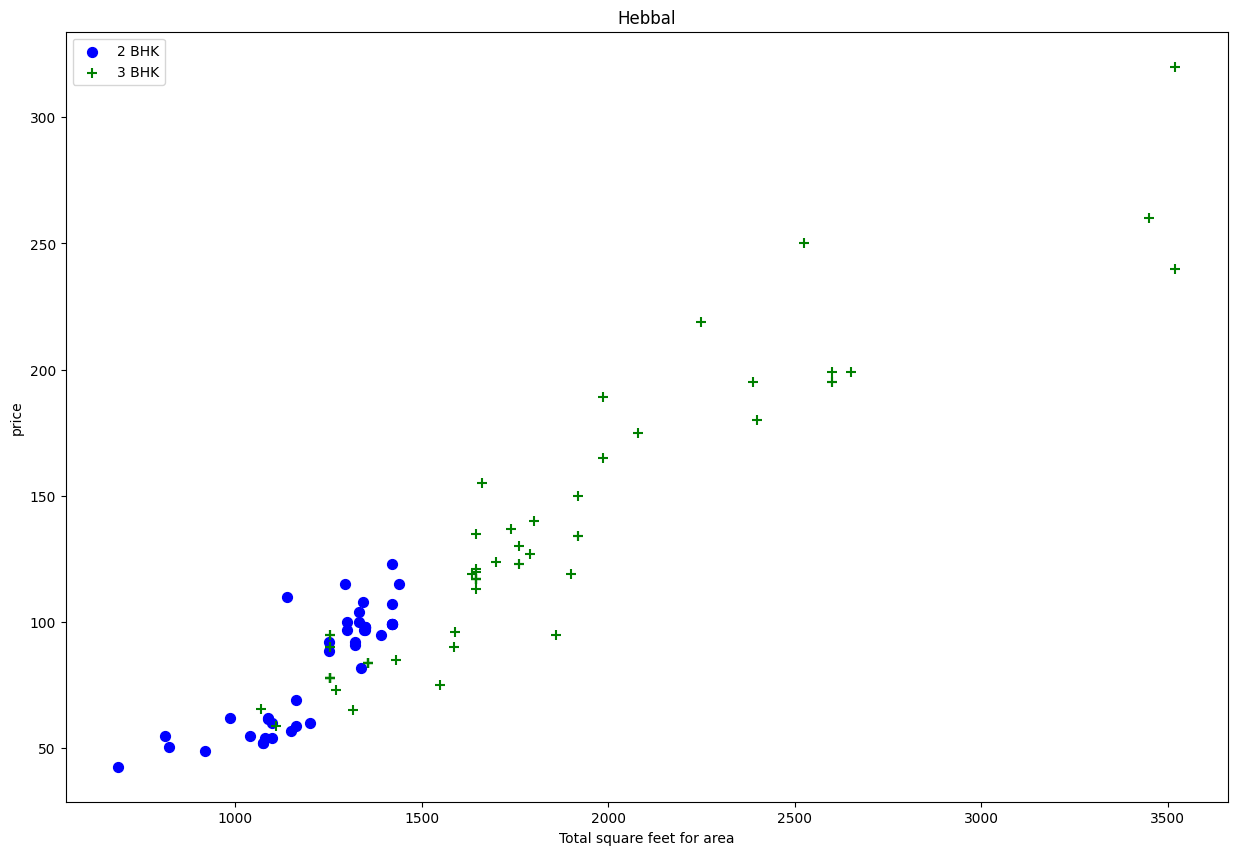

In [45]:
plt_scatter_chart(df7,'Hebbal')

The data is checked location by location to compare property prices fairly within the same area.

For each location, the average price per square foot of smaller BHK homes is calculated.

Then, higher BHK homes that are priced lower per sqft than the smaller ones are identified.

Those few unrealistic higher-BHK entries are removed from the dataset to keep only logical, consistent price patterns.

In [46]:
def remove_bhk_outliers(df):
    exclude_indices=np.array([])
    for location,location_df in df.groupby('location'):
        bhk_stats={}
        for bhk,bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk]={
                "mean":np.mean(bhk_df.price_per_sqft),
                "std":np.std(bhk_df.price_per_sqft),
                "count":bhk_df.shape[0]
            }
        for bhk,bhk_df in location_df.groupby('bhk'):
            stats=bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices=np.append(exclude_indices,bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis='index')

df8=remove_bhk_outliers(df7)
df8.shape

(7329, 7)

2 BHK vs 3 BHK Price for 'Hebbal' (After Outlier Removal): This plot demonstrated that after cleaning, 3 BHK properties in Hebbal were generally priced higher than 2 BHKs, confirming corrected pricing logic.

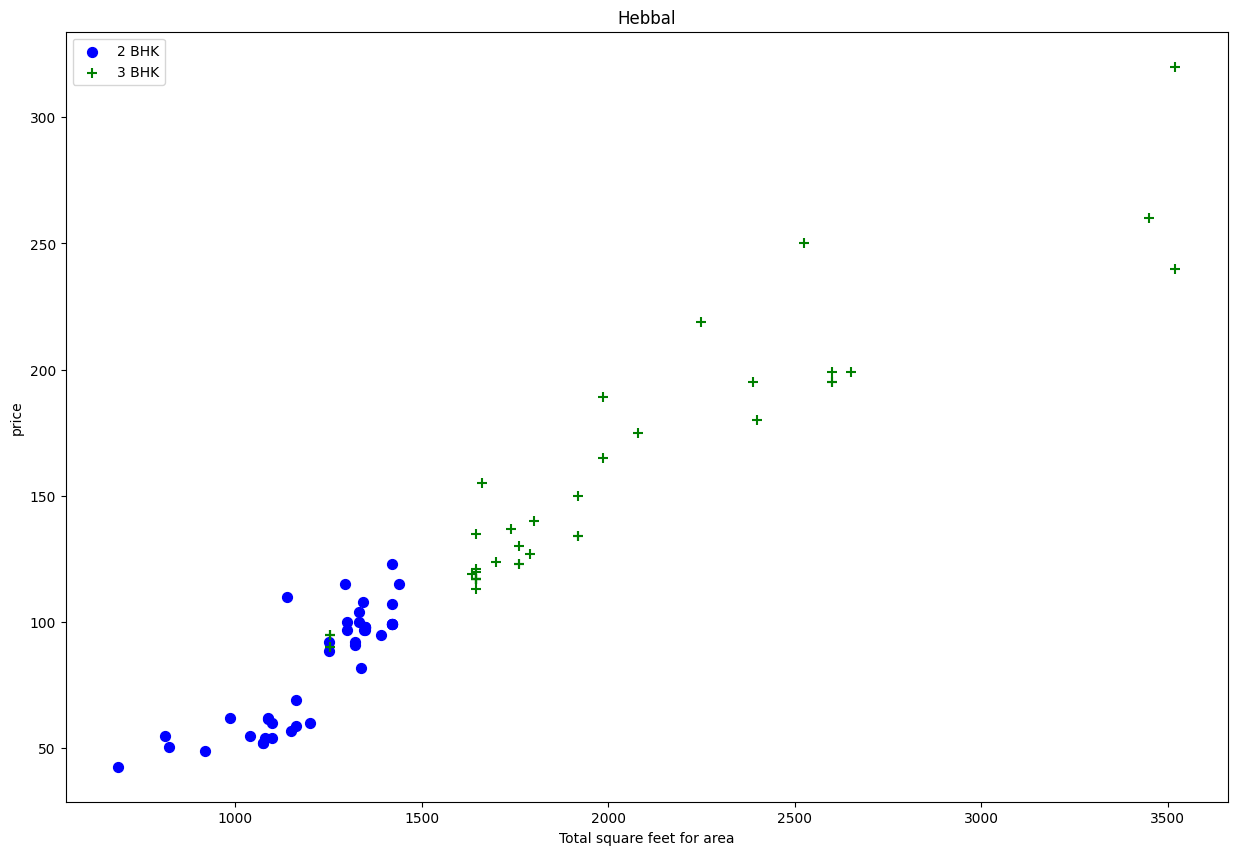

In [47]:
plt_scatter_chart(df8,'Hebbal')

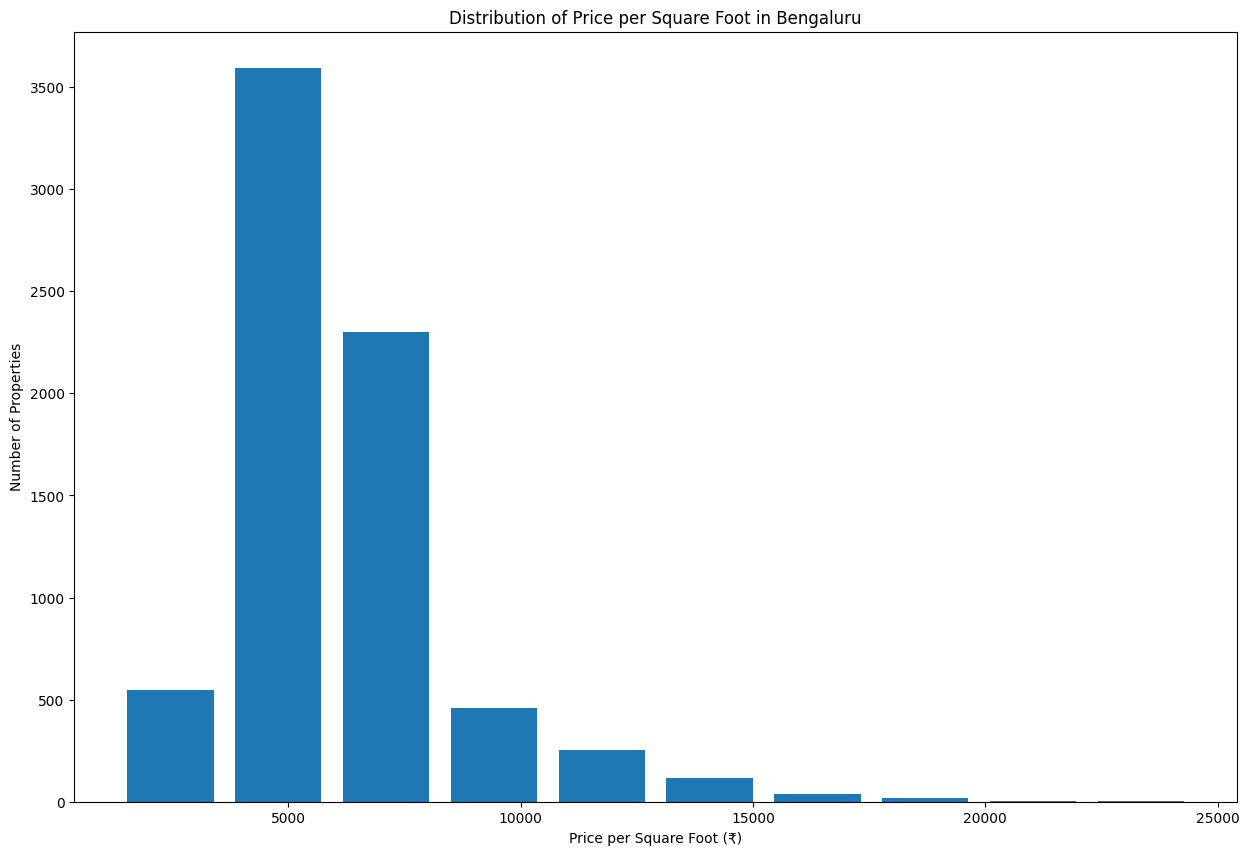

In [48]:
matplotlib.rcParams['figure.figsize'] = (15, 10)
plt.hist(df8.price_per_sqft, rwidth=0.8)
plt.xlabel("Price per Square Foot (₹)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Price per Square Foot in Bengaluru")
plt.show()

Finding bath outliers


In [49]:
df8[df8.bath>10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5277,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10.0,4000.000000
8486,other,10 BHK,12000.0,12.0,525.0,10.0,4375.000000
8575,other,16 BHK,10000.0,16.0,550.0,16.0,5500.000000
9308,other,11 BHK,6000.0,12.0,150.0,11.0,2500.000000
9639,other,13 BHK,5425.0,13.0,275.0,13.0,5069.124424


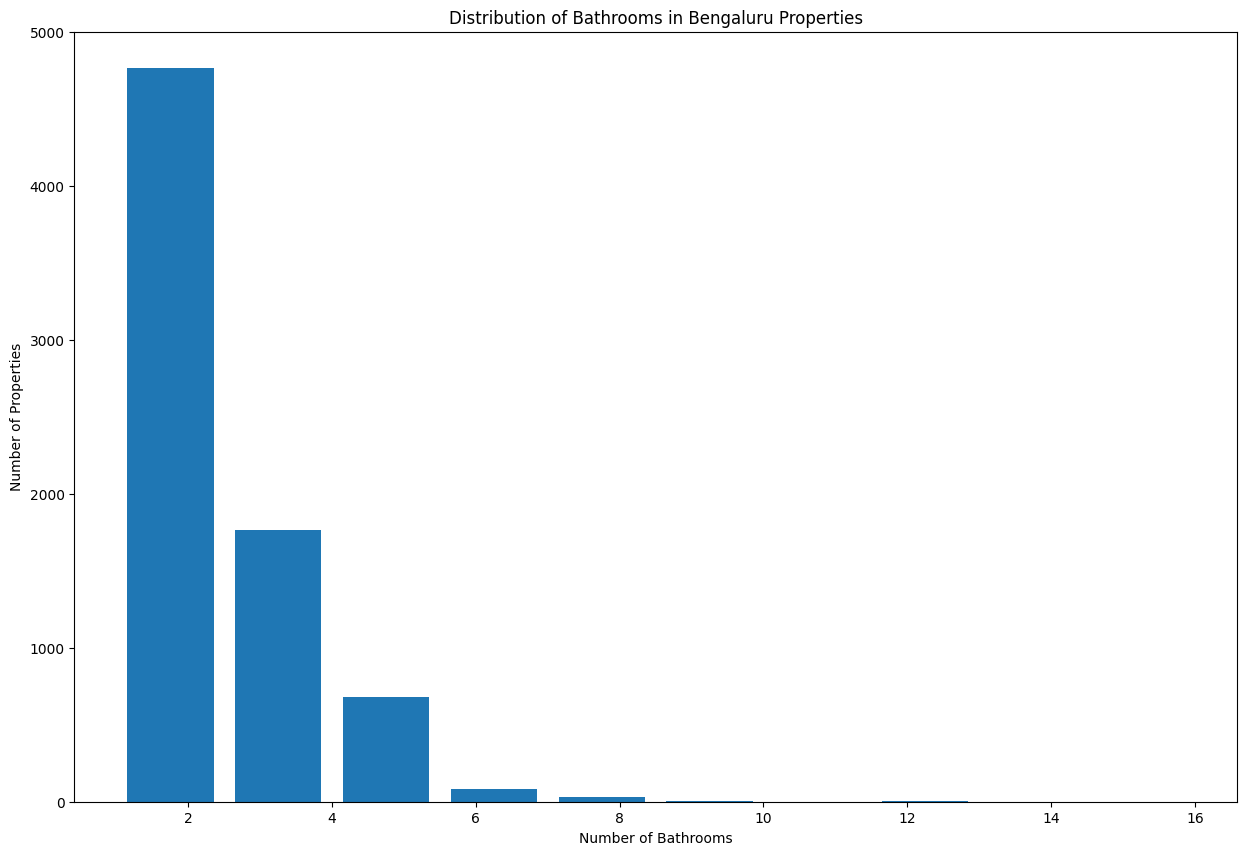

In [50]:

# Plot histogram
plt.hist(df8.bath, rwidth=0.8)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Properties")
plt.title("Distribution of Bathrooms in Bengaluru Properties")
plt.show()

**Removing outliers**

Now  keeps only those rows where the number of bathrooms is less than (BHK + 2).

In [51]:
df9=df8[df8.bath<df8.bhk+2]

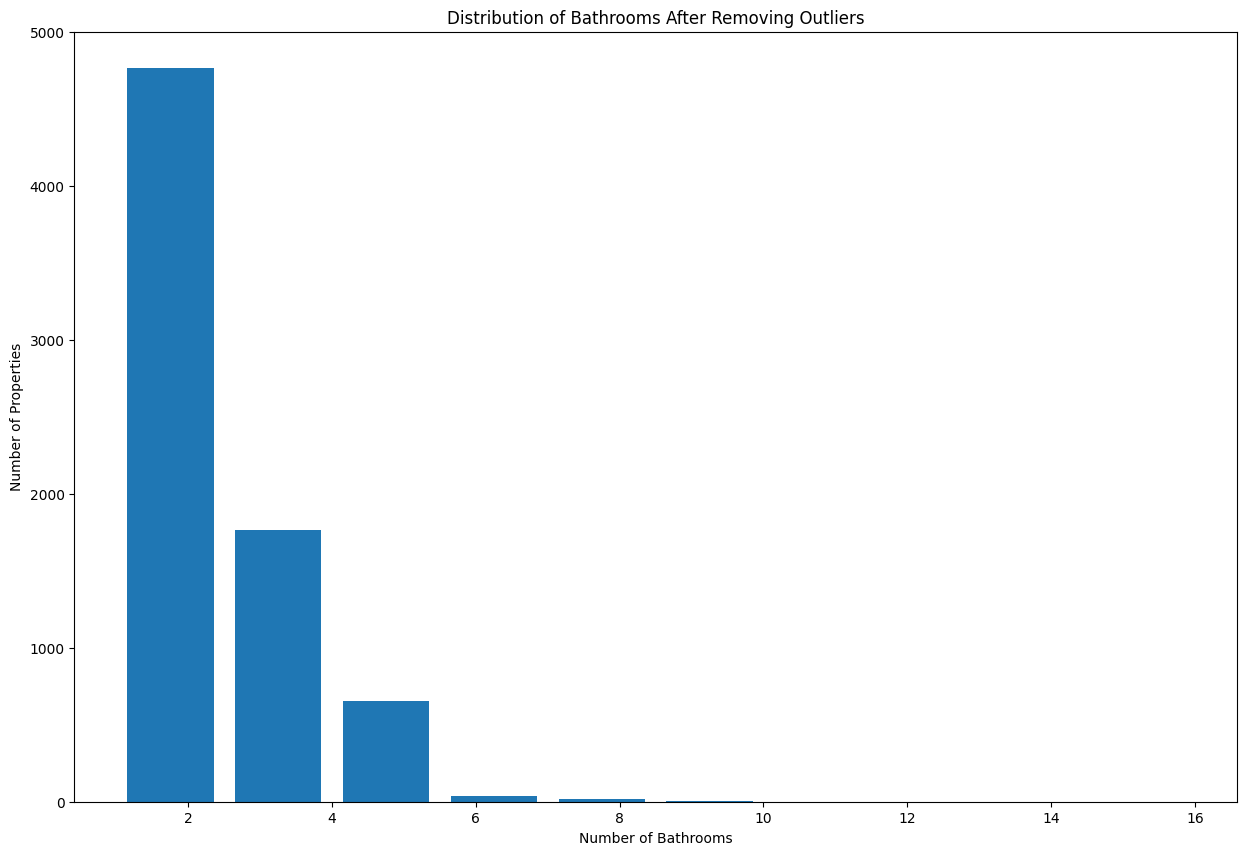

In [52]:

plt.hist(df9.bath, rwidth=0.8)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Properties")
plt.title("Distribution of Bathrooms After Removing Outliers")
plt.show()

In [53]:
df9.shape

(7251, 7)

Boxplot of Price by Location (Top 10 only)

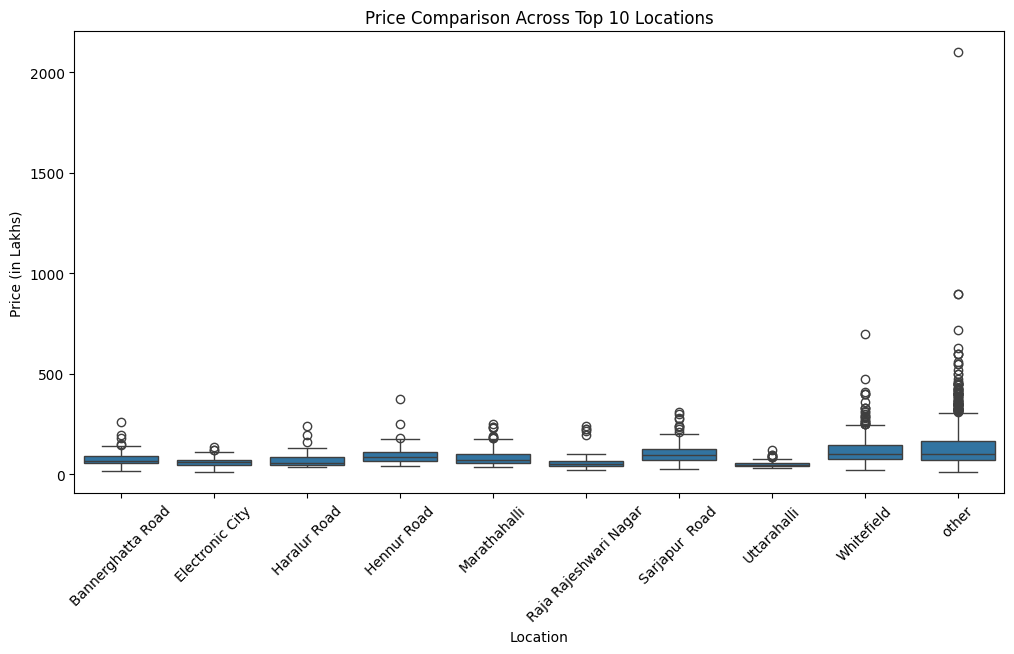

In [54]:
top_locations = df9['location'].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.boxplot(x='location', y='price', data=df9[df9['location'].isin(top_locations)])
plt.xticks(rotation=45)
plt.title("Price Comparison Across Top 10 Locations")
plt.xlabel("Location")
plt.ylabel("Price (in Lakhs)")
plt.show()


In [55]:
df10=df9.drop(['price_per_sqft','size'],axis=1)

In [56]:
df10.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4.0
1,1st Block Jayanagar,1630.0,3.0,194.0,3.0
2,1st Block Jayanagar,1875.0,2.0,235.0,3.0
3,1st Block Jayanagar,1200.0,2.0,130.0,3.0
4,1st Block Jayanagar,1235.0,2.0,148.0,2.0


We use pd.get_dummies() to convert
the location column into multiple numeric columns (one per area).

Then we merge them with the main dataset and drop the ‘other’ column to avoid multicollinearity.

In [57]:
dummies=pd.get_dummies(df10.location)
df11=pd.concat([df10,dummies.drop('other',axis=1)],axis='columns')

In [58]:
df11.head()

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st Block Jayanagar,1630.0,3.0,194.0,3.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st Block Jayanagar,1875.0,2.0,235.0,3.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st Block Jayanagar,1200.0,2.0,130.0,3.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st Block Jayanagar,1235.0,2.0,148.0,2.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [59]:
df12=df11.drop('location',axis=1)

In [60]:
df12.shape

(7251, 245)

In [61]:
df12.head(3)

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,194.0,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,235.0,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [62]:
print(f"Original shape of df12: {df12.shape}")


duplicate_rows = df12.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")


if duplicate_rows > 0:
    df12 = df12.drop_duplicates().copy()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")


print(f"New shape of df12 after removing duplicates: {df12.shape}")
print(f"Number of duplicate rows after removal: {df12.duplicated().sum()}")

Original shape of df12: (7251, 245)
Number of duplicate rows found: 619
Duplicate rows removed.
New shape of df12 after removing duplicates: (6632, 245)
Number of duplicate rows after removal: 0


### Data Cleaning & EDA: Step-by-Step Breakdown

1.  **Data Loading and Initial Inspection**: Loaded the `bengaluru_house_prices.csv` into `df1`, displaying its head and shape for an initial overview.
2.  **Irrelevant Column Removal**: Dropped `area_type`, `availability`, `society`, and `balcony` from `df1` to create `df2`, streamlining the dataset.
3.  **Missing Value Handling**: Identified and removed rows with `NaN` values from `df2` to create `df3`, ensuring data completeness.
4.  **Feature Engineering (`bhk`)**: Extracted numerical `bhk` (bedrooms, hall, kitchen) from the `size` column in `df3`.
5.  **`total_sqft` Cleaning**: Processed the `total_sqft` column in `df4` to convert ranges (e.g., '1100-1200') into averages and ensured all entries were numerical.
6.  **`price_per_sqft` Calculation**: Created a normalized `price_per_sqft` feature in `df5` to aid in comparative analysis and outlier detection.
7.  **Location Dimensionality Reduction**: Cleaned and grouped less frequent locations (those with <= 10 occurrences) into an 'other' category in `df5` to manage high cardinality.
8.  **Outlier Removal (Per `bhk` sqft)**: Removed properties in `df6` where `total_sqft` per `bhk` was unrealistically low (below 300 sqft/BHK).
9.  **Outlier Removal (`price_per_sqft`)**: Applied statistical outlier removal in `df7` by filtering `price_per_sqft` values outside one standard deviation within each location.
10. **Outlier Removal (BHK vs. Price)**: Used domain-specific logic in `df8` to remove cases where a higher `bhk` property was significantly cheaper per square foot than a lower `bhk` property in the same area.
11. **Outlier Removal (Bathrooms)**: Filtered out properties in `df9` with an implausibly high number of bathrooms (greater than `bhk` + 2).
12. **Final Feature Selection**: Dropped `price_per_sqft` and the original `size` columns from `df9` to create `df10`, leaving only features relevant for modeling.
13. **One-Hot Encoding**: Converted the `location` categorical variable into numerical dummy variables in `df11` and `df12`, dropping the original `location` column and the 'other' dummy to prevent multicollinearity.
14. **Duplicate Row Removal**: Ensured data uniqueness in `df12` by identifying and removing any duplicate rows.
15. **Exploratory Data Analysis (Visualizations)**: Generated various plots including histograms for `total_sqft`, `bath`, `bhk`, and `price`, a scatter plot of `total_sqft` vs. `price`, and a correlation heatmap of numerical features, providing visual insights into the data.

In [63]:
df12.head()

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,194.0,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,235.0,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,130.0,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,148.0,2.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


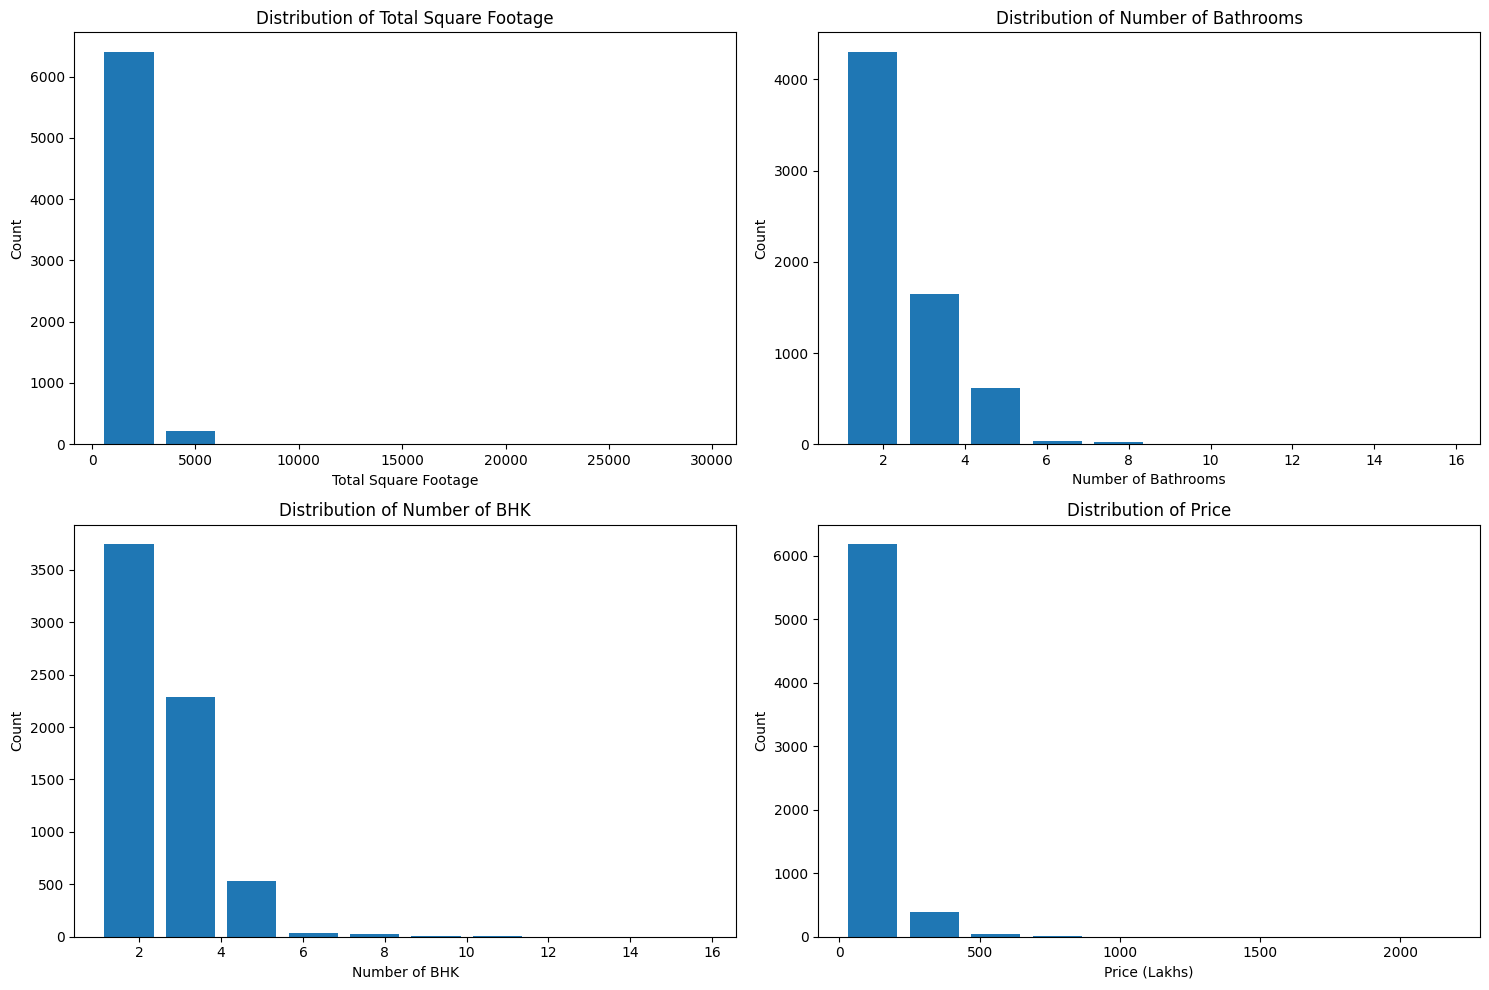

In [64]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Histogram for 'total_sqft'
axes[0, 0].hist(df12['total_sqft'], rwidth=0.8)
axes[0, 0].set_title('Distribution of Total Square Footage')
axes[0, 0].set_xlabel('Total Square Footage')
axes[0, 0].set_ylabel('Count')

# Histogram for 'bath'
axes[0, 1].hist(df12['bath'], rwidth=0.8)
axes[0, 1].set_title('Distribution of Number of Bathrooms')
axes[0, 1].set_xlabel('Number of Bathrooms')
axes[0, 1].set_ylabel('Count')

# Histogram for 'bhk'
axes[1, 0].hist(df12['bhk'], rwidth=0.8)
axes[1, 0].set_title('Distribution of Number of BHK')
axes[1, 0].set_xlabel('Number of BHK')
axes[1, 0].set_ylabel('Count')

# Histogram for 'price'
axes[1, 1].hist(df12['price'], rwidth=0.8)
axes[1, 1].set_title('Distribution of Price')
axes[1, 1].set_xlabel('Price (Lakhs)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


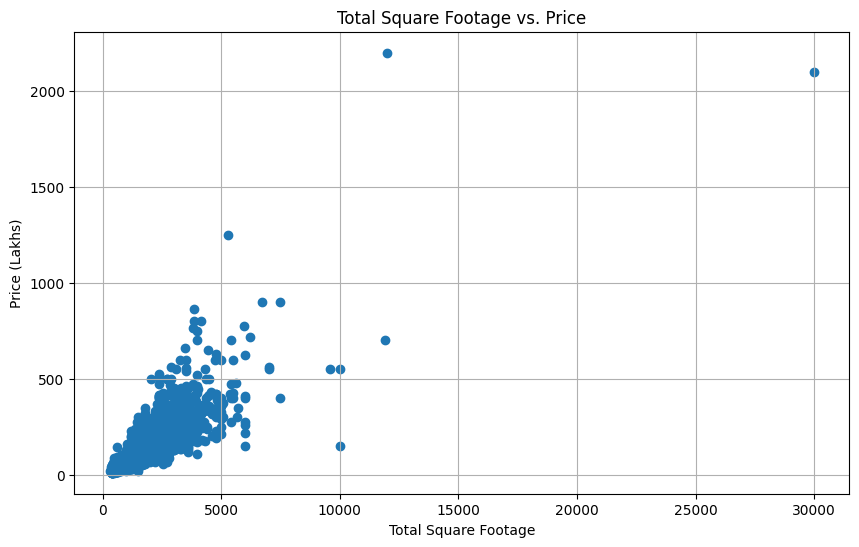

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df12['total_sqft'], df12['price'])
plt.title('Total Square Footage vs. Price')
plt.xlabel('Total Square Footage')
plt.ylabel('Price (Lakhs)')
plt.grid(True)
plt.show()

In [66]:
df12['total_sqft'].corr(df12['price'])

np.float64(0.8399598723556498)

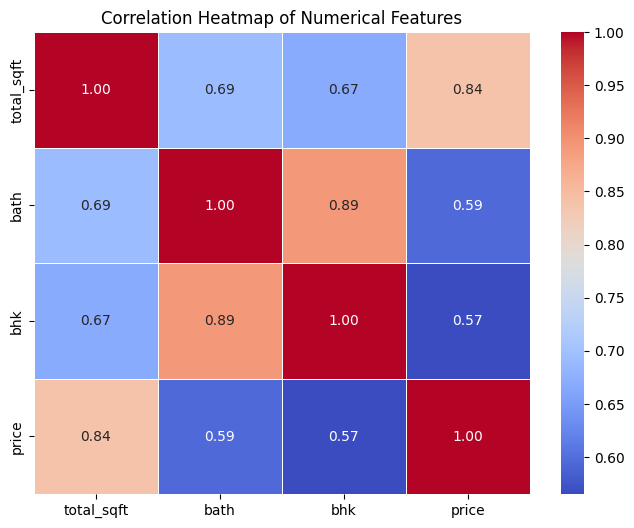

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the relevant numerical columns
correlation_df = df12[['total_sqft', 'bath', 'bhk', 'price']]

# 2. Calculate the pairwise correlation matrix
correlation_matrix = correlation_df.corr()

# 3. Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

# 4. Set a descriptive title for the heatmap
plt.title('Correlation Heatmap of Numerical Features')

# 5. Display the plot
plt.show()

### Separating Features (X) and Target (y)

This step is fundamental in preparing data for machine learning. The dataset `df12` is split into two distinct parts:

*   **`X` (Features)**: This DataFrame contains all the independent variables or input features that will be used to predict the target. In this case, `X` includes `total_sqft`, `bath`, `bhk`, and all the one-hot encoded location columns, excluding the 'price' column.
*   **`y` (Target)**: This Series contains the dependent variable, which is what the machine learning model will try to predict. Here, `y` holds the 'price' of the houses.

In [68]:
X=df12.drop('price',axis=1)
y=df12.price
X

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,4.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,3.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,3.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10224,1490.0,3.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10226,1650.0,1.0,2.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10230,1155.0,2.0,2.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10233,1800.0,1.0,1.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [69]:
from sklearn.model_selection import train_test_split

The dataset is split into training and testing sets using train_test_split().
X_train and y_train are used to train the Linear Regression model on Bengaluru housing data.
X_test and y_test are used to test how well the model predicts unseen house prices.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [71]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

The R² score tells how well the model explains the differences in prices among all houses.
A higher value means the model accurately captures most of the variation in house prices based on features like area, BHK, and location.

In [72]:
lr.score(X_test,y_test)

0.8323861137422321

Uses the trained model (lr) to make predictions on unseen data (X_test).

In [73]:
pred=lr.predict(X_test)
pred

array([119.59233147,  36.12935465,  69.68023003, ..., 134.72787464,
       178.88703383,  70.62810631])

Cross-validation checks how stable the Linear Regression model is by training and testing it multiple times on different random splits.
Consistently high R² scores mean the model performs reliably on different subsets of Bengaluru housing data.

In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit
cv=ShuffleSplit(n_splits=5,test_size=0.2,random_state=10)
cross_val_score(LinearRegression(),X,y,cv=cv)

array([0.83238611, 0.79299853, 0.85141512, 0.85240592, 0.85748841])

In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

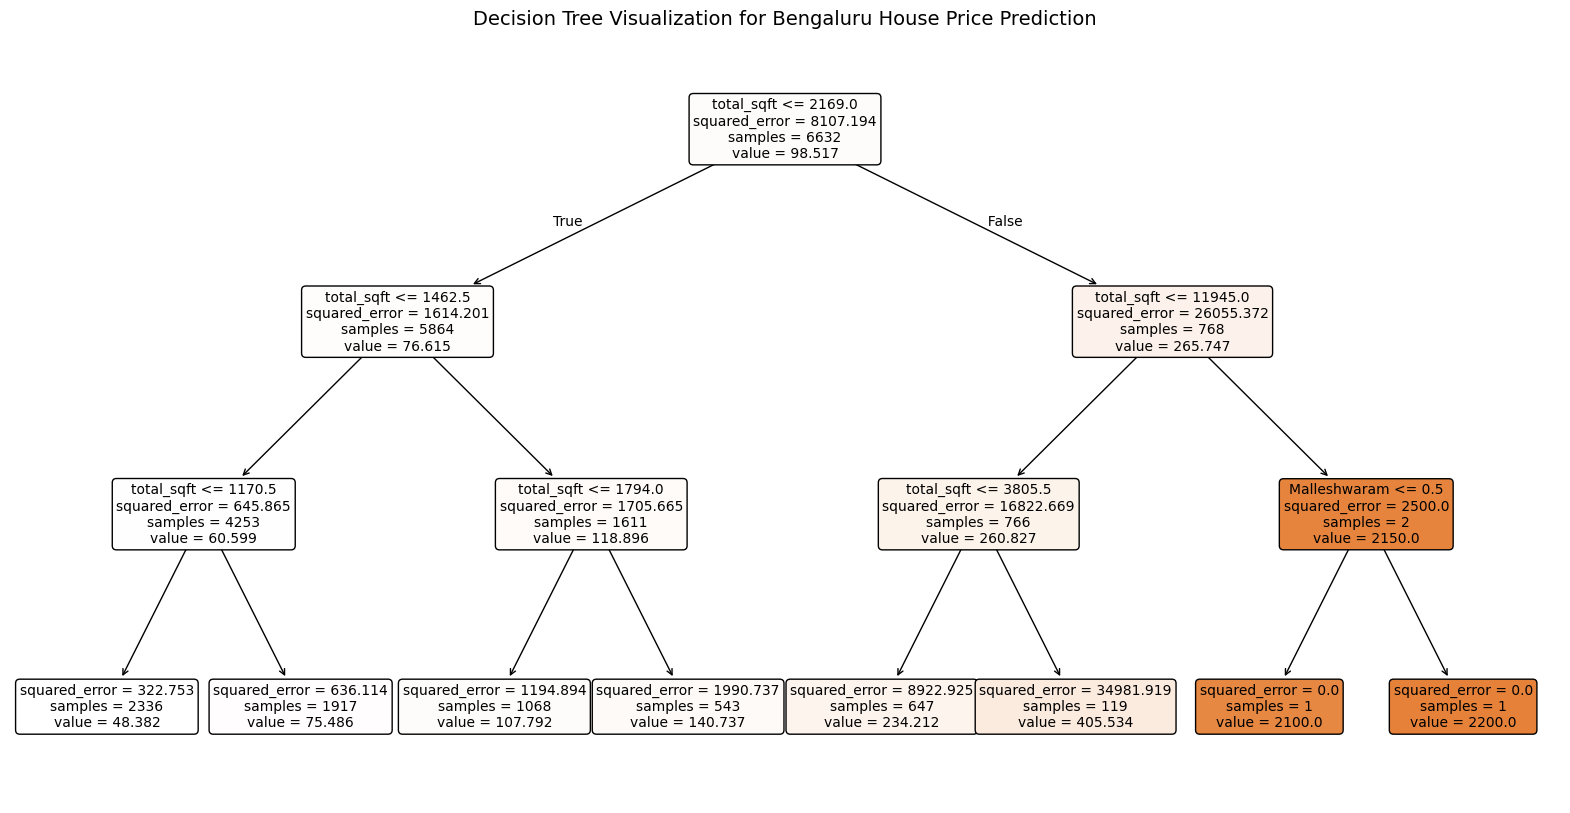

In [76]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Train a simple Decision Tree model on your data
model = DecisionTreeRegressor(max_depth=3, random_state=10)
model.fit(X, y)

# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization for Bengaluru House Price Prediction", fontsize=14)
plt.show()

Finding the Best Model with GridSearchCV
This function (find_best_model_using_gridsearchcv) helps you figure out which machine learning model works best for your data and what settings (parameters) are ideal for that model. It automatically tests different models (like Linear Regression and Decision Tree) with various combinations of their settings, using a technique called cross-validation to ensure reliable results. It then reports back the best-performing model and its optimal settings.




In [77]:
def find_best_model_using_gridsearchcv(X,y):
    algos={
        'linear_regression':{
            'model':LinearRegression(),
            'params':{
#                 'normalize':[True,False]
            }
        },
        'decisiontree':{
            'model':DecisionTreeRegressor(),
            'params':{
                'criterion':['squared_error','friedman_mse'],
                'splitter':['best','random']
            }
        }
    }
    scores=[]
    cv=ShuffleSplit(n_splits=5,test_size=0.2,random_state=10)
    for algo_name,config in algos.items():
        gs=GridSearchCV(config['model'],config['params'],cv=cv,return_train_score=False)
        gs.fit(X,y)
        scores.append({
            'model':algo_name,
            'best_score':gs.best_score_,
            'best_params':gs.best_params_
        })
    return pd.DataFrame(scores,columns=['model','best_score','best_params'])

In [78]:
model_comparison_results = find_best_model_using_gridsearchcv(X, y)
print("Model comparison results:")
display(model_comparison_results)

Model comparison results:


,model,best_score,best_params
0,linear_regression,0.837339,{}
1,decisiontree,0.678636,"{'criterion': 'squared_error', 'splitter': 'be..."


In [79]:
df12.head(3)

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,194.0,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,235.0,3.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [80]:
np.where(X.columns=="5th Block Hbr Layout")[0][0]

np.int64(7)

In [81]:
X.columns

Index(['total_sqft', 'bath', 'bhk', '1st Block Jayanagar',
       '1st Phase JP Nagar', '2nd Phase Judicial Layout',
       '2nd Stage Nagarbhavi', '5th Block Hbr Layout', '5th Phase JP Nagar',
       '6th Phase JP Nagar',
       ...
       'Vijayanagar', 'Vishveshwarya Layout', 'Vishwapriya Layout',
       'Vittasandra', 'Whitefield', 'Yelachenahalli', 'Yelahanka',
       'Yelahanka New Town', 'Yelenahalli', 'Yeshwanthpur'],
      dtype='object', length=244)

In [82]:
def predicted_price(location,sqft,bath,bhk):
    loc_index = np.where(X.columns==location)[0][0]
    x=np.zeros(len(X.columns))

    x[0]=sqft
    x[1]=bath
    x[2]=bhk
    # Each row has 1 only in its actual location column.
    #So during prediction, you must do the same thing — set exactly one location column to 1 (and all others to 0).
    if(loc_index>=0):
        x[loc_index]=1

    # Convert the numpy array to a DataFrame with correct column names
    # This resolves the UserWarning about missing feature names
    input_df = pd.DataFrame([x], columns=X.columns)
    return lr.predict(input_df)[0]

In [83]:
predicted_val = predicted_price('1st Phase JP Nagar',1000,2,2)
print(f"The predicted price for a 2 BHK, 1000 sqft, 2 bath property in 1st Phase JP Nagar is: {predicted_val:.2f} Lakhs.")

The predicted price for a 2 BHK, 1000 sqft, 2 bath property in 1st Phase JP Nagar is: 87.99 Lakhs.


In [84]:
predicted_val = predicted_price('Whitefield',2000,2,2)
print(f"The predicted price for a 2 BHK, 1000 sqft, 2 bath property in Whitefield is: {predicted_val:.2f} Lakhs.")

The predicted price for a 2 BHK, 1000 sqft, 2 bath property in Whitefield is: 133.58 Lakhs.


# **conclusion**

This project successfully developed a house price prediction model for Bengaluru, starting with a comprehensive data cleaning and exploratory data analysis phase to refine the raw data. Key insights from visualizations confirmed strong correlations between property size, bathrooms, BHK, and price. After rigorous outlier removal and one-hot encoding, the dataset was prepared for modeling. A comparative analysis using GridSearchCV revealed that a Linear Regression model significantly outperformed a Decision Tree Regressor, achieving an impressive R-squared score of approximately 83.7%. The final model provides a reliable tool to predict property prices based on location, square footage, bathrooms, and BHK, demonstrating its practical utility for real estate valuation.

In [85]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score


svm_model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1))

# Evaluate with cross-validation
scores = cross_val_score(svm_model, X, y, cv=5)
print("SVR R² Scores for each fold:", scores)
print("Average R² Score:", scores.mean())


SVR R² Scores for each fold: [0.53314539 0.70052469 0.38440692 0.60334846 0.07201635]
Average R² Score: 0.4586883623072623


In [86]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=10)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
print("R² Score for Random Forest:", r2)


R² Score for Random Forest: 0.7819661619537993
